In [1]:
# from nupack import *
import sys
sys.path.insert(0, '/Users/Mark/build/nupack/api')
from nudev import *
import math
import matplotlib.pyplot as plt

# Secondary structure model specification

Specify a free energy model including:
- `material`: the parameter set description to use. If 'RNA' or 'DNA' are specified, the default parameter sets for those materials will be used. A full parameter file may be specified, for example, by `parameters=nupack.ParameterFile(material='RNA', dG='rna1995.dG', dH='rna1995.dH')`
- `ensemble`: the recursions to use, from `['nostacking', 'stacking', 'none', 'min', 'all']` (default=`'stacking'`). Using `'nostacking'`, no dangle or stacking energies will be incorporated. Using `'min'`, a dangle energy is incorporated for each unpaired base flanking a duplex (a base flanking two duplexes contributes only the minimum of the two possible dangle energies). Using `'all'`, a dangle energy is incorporated for each base flanking a duplex regardless of whether it is paired. Using `'stacking'`, every possible coaxial stacking and dangle state is incorporated into the recursions.
- `celsius`: the temperature, in Kelvin (default=`310.15`)
- `magnesium`: the magnesium ion concentration $\text{Mg}^{2+}$, in moles per liter (default=`0.0`)
- `sodium`: the sodium ion concentration $\text{Na}^{+}$, in moles per liter (default=`1.0`)
- `allow_wobbles`: whether wobble pairs (G$\cdot$U or G$\cdot$T) are allowed (default=`True`)

In [2]:
model = Model(material='DNA', celsius=23, magnesium=0, sodium=0.1, ensemble='stacking')

# Example 2: Partition function for a complex.
Calculate the partition function for a complex of four DNA strands at 23 ◦C, two of which are indistinguishable.

## Input file contents:

```
3
AGTCTAGGATTCGGCGTGGGTTAA 
TTAACCCACGCCGAATCCTAGACTCAAAGTAGTCTAGGATTCGGCGTG
AGTCTAGGATTCGGCGTGGGTTAACACGCCGAATCCTAGACTACTTTG
1223
```

## Command: 

```bash
pfunc -T 23 -multi -material dna $NUPACKHOME/doc/examples/complex-analysis/advanced/input/hcr
```

In [3]:
strands = (
    'AGTCTAGGATTCGGCGTGGGTTAA',
    'TTAACCCACGCCGAATCCTAGACTCAAAGTAGTCTAGGATTCGGCGTG',
    'TTAACCCACGCCGAATCCTAGACTCAAAGTAGTCTAGGATTCGGCGTG',
    'AGTCTAGGATTCGGCGTGGGTTAACACGCCGAATCCTAGACTACTTTG'
)

result = pfunc(strands, model=model)

print('Partition function = %.3e' % result)
print('Free energy = %.2f kcal/mol' % result.free_energy)

Partition function = 8.775e+80
Free energy = -109.68 kcal/mol


# Example 3: Test tube analysis. 

Calculate the partition function, equilibrium pair probabilities, MFE structure(s), and equilibrium concentration for each complex in a test tube containing three DNA strand species that interact to form all complex species of up to four strands, plus additional larger complexes specified in a .list file.

## Input file contents:

```
3
AGTCTAGGATTCGGCGTGGGTTAA
TTAACCCACGCCGAATCCTAGACTCAAAGTAGTCTAGGATTCGGCGTG
AGTCTAGGATTCGGCGTGGGTTAACACGCCGAATCCTAGACTACTTTG
4
```

## List file contents:

```
1 2 2 3 3
1 2 3 2 3
2 3 2 3 2
1 2 2 2 3 3
```

## Strand concentrations file contents:

```
1e-6
1.1e-6
0.9e-6
```

## Commands: 

```bash
complexes -T 23 -material dna -pairs -mfe -degenerate $NUPACKHOME/doc/examples/tube-analysis/advanced/input/hcr
concentrations -pairs $NUPACKHOME/doc/examples/tube-analysis/advanced/input/hcr
```

In [4]:
strands = [
    Strand('A', "AGTCTAGGATTCGGCGTGGGTTAA"),
    Strand('B', "TTAACCCACGCCGAATCCTAGACTCAAAGTAGTCTAGGATTCGGCGTG"),
    Strand('C', "AGTCTAGGATTCGGCGTGGGTTAACACGCCGAATCCTAGACTACTTTG")
]

larger_complex_specs = [
    [1, 2, 2, 3, 3],
    [1, 2, 3, 2, 3],
    [2, 3, 2, 3, 2],
    [1, 2, 2, 2, 3, 3],
]

additional_complexes = [[strands[i-1] for i in x] for x in larger_complex_specs]

tube = Tube('tube', strands, concentrations=[1e-6, 1.1e-6, 0.9e-6], max_size=4, include=additional_complexes)

result = tube_analysis([tube], compute=['mfe', 'pairs'])
result

,complex,partition_function,free_energy,min_free_energy
0,[B],4.8848e+21,-30.78,-30.199999
1,[B+B+C+C],1.8930e+97,-138.05,-134.744049
2,[B+C+B+C+B],4.4855e+119,-169.80,-163.325394
3,[B+B+B],2.5281e+69,-98.49,-94.585609
4,[A+A+C],5.2818e+35,-50.70,-45.862705
5,[A+B+A+C],9.2957e+71,-102.13,-97.544052
6,[A+A+A+A],3.0952e+23,-33.34,-25.489653
7,[A+C+C+B],1.5037e+82,-116.62,-111.744064
8,[B+B+B+B],2.5039e+93,-132.54,-126.989693
9,[A+C+B+B],6.0823e+81,-116.06,-110.344055


Complex = [B]
    Strand indices = [1]
    Concentration = 1.248e-08 M
    Complex free energy = -30.779 kcal/mol
    MFE = -30.200 kcal/mol
    MFE structure = ......((((((((((((((((((......))))))))))))))))))


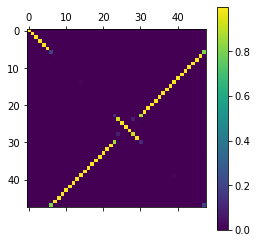

Complex = [B+B+C+C]
    Strand indices = [1, 1, 2, 2]
    Concentration = 2.875e-27 M
    Complex free energy = -138.049 kcal/mol
    MFE = -134.744 kcal/mol
    MFE structure = ((((((((((((((((((((((((((((((((((((((((((((((((+((((((((((((((((((((((((((..((((((...))))..)).))+))))))))))))))))))))))))))))))))))))))))))))))))+))))))))))))))))))))))))........................


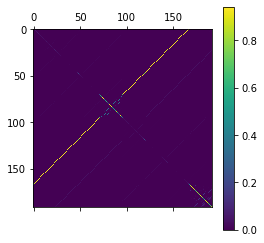

Complex = [B+C+B+C+B]
    Strand indices = [1, 2, 1, 2, 1]
    Concentration = 3.156e-36 M
    Complex free energy = -169.802 kcal/mol
    MFE = -163.325 kcal/mol
    MFE structure = ((((((((((((((((((((((((((..((((((...))))..)).))+))))))))))))))))))))))))((((((((((((((((((((((((+...(..((((((((((((((((((......))))))))))))))))))+.(((((((((((((((((((((((........................+))))))))))))))))))))))))))))))))))))))))))))))))


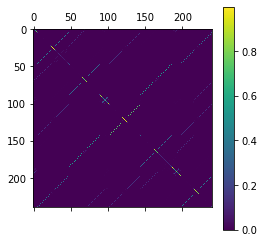

Complex = [B+B+B]
    Strand indices = [1, 1, 1]
    Concentration = 4.624e-24 M
    Complex free energy = -98.492 kcal/mol
    MFE = -94.586 kcal/mol
    MFE structure = ((((..((((((((((((((((((......))))))))))))))))))+))))..((((((((((((((((((......((((((((((((((((((+......))))))))))))))))))......))))))))))))))))))


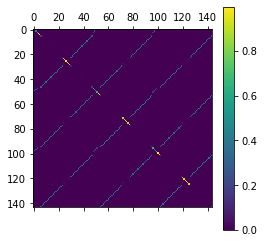

Complex = [A+A+C]
    Strand indices = [0, 0, 2]
    Concentration = 2.910e-16 M
    Complex free energy = -50.695 kcal/mol
    MFE = -45.863 kcal/mol
    MFE structure = .((((.((((..(((....)))..+.)))).)))).......((((...+((((((((((((((((((......))))))))))))))))))))))..


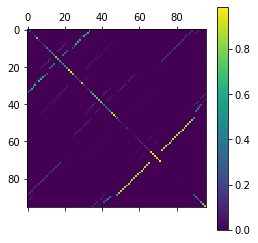

Complex = [A+B+A+C]
    Strand indices = [0, 1, 0, 2]
    Concentration = 2.373e-11 M
    Complex free energy = -102.132 kcal/mol
    MFE = -97.544 kcal/mol
    MFE structure = (((((((((((((((((((((((.+.)))))))))))))))))))))))((((((((((((((((((((((((+.......((((((((.((((((..+.......)))))))).))))))..))))))))))))))))))))))))


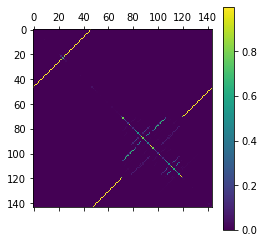

Complex = [A+A+A+A]
    Strand indices = [0, 0, 0, 0]
    Concentration = 3.322e-19 M
    Complex free energy = -33.336 kcal/mol
    MFE = -25.490 kcal/mol
    MFE structure = .((((.((((((.((((.(.....+(((((.((((..(((....)))..+.)))).)))))).)))).).....+))))).))))..(((....)))..


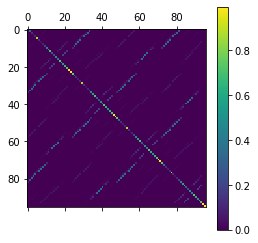

Complex = [A+C+C+B]
    Strand indices = [0, 2, 2, 1]
    Concentration = 8.231e-22 M
    Complex free energy = -116.620 kcal/mol
    MFE = -111.744 kcal/mol
    MFE structure = (((((((((((((((((((((((.+((((((((((((((((((......((((((((((((((((((......+))))))))))))))))))......))))))))))))))))))(.....+))))))))))))))))))))))))((..((((((...))))..)).))


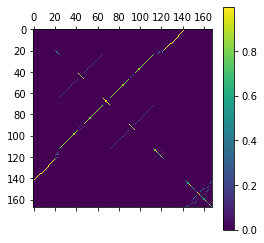

Complex = [B+B+B+B]
    Strand indices = [1, 1, 1, 1]
    Concentration = 1.592e-31 M
    Complex free energy = -132.545 kcal/mol
    MFE = -126.990 kcal/mol
    MFE structure = ......((((((((((((((((((......((((((((((((((((((+((((..((((((((((((((((((......((((((((((((((((((+......))))))))))))))))))......))))))))))))))))))+))))..))))))))))))))))))......))))))))))))))))))


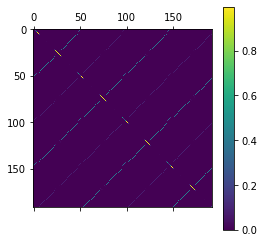

Complex = [A+C+B+B]
    Strand indices = [0, 2, 1, 1]
    Concentration = 4.308e-22 M
    Complex free energy = -116.062 kcal/mol
    MFE = -110.344 kcal/mol
    MFE structure = (((((((((((((((((((((((.+((((((((((((((((((......))))))))))))))))))(.....+))))))))))))))))))))))))......((((...)))).((....+....))((((((((((((((((((......))))))))))))))))))


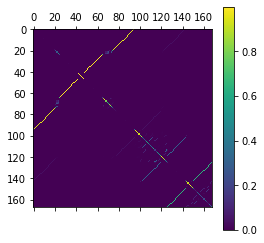

Complex = [A+B+C+B+C]
    Strand indices = [0, 1, 2, 1, 2]
    Concentration = 1.261e-15 M
    Complex free energy = -169.865 kcal/mol
    MFE = -165.125 kcal/mol
    MFE structure = (((((((((((((((((((((((.+.)))))))))))))))))))))))((((((((((((((((((((((..+((((((((((((((((((......))))))))))))))))))....((+((((((((((((((((((((((((((..((((((...))))..)).))+))))))))))))))))))))))))))))))))))))))))))))))))


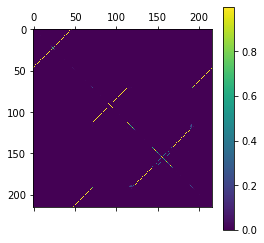

Complex = [A+B+C]
    Strand indices = [0, 1, 2]
    Concentration = 1.159e-07 M
    Complex free energy = -92.073 kcal/mol
    MFE = -89.763 kcal/mol
    MFE structure = (((((((((((((((((((((((.+.)))))))))))))))))))))))((((((((((((((((((((((((+.......(((((.....)))))..))))))))))))))))))))))))


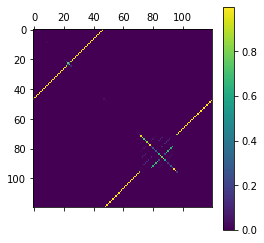

Complex = [A+A+A+C]
    Strand indices = [0, 0, 0, 2]
    Concentration = 5.980e-20 M
    Complex free energy = -60.757 kcal/mol
    MFE = -53.944 kcal/mol
    MFE structure = .((((.((((((.(((((((((..+.......))))).)))).).....+))))).)))).......((((...+((((((((((((((((((......))))))))))))))))))))))..


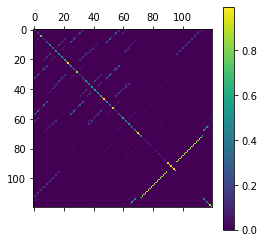

Complex = [A+B+B+C]
    Strand indices = [0, 1, 1, 2]
    Concentration = 1.396e-07 M
    Complex free energy = -136.655 kcal/mol
    MFE = -134.344 kcal/mol
    MFE structure = (((((((((((((((((((((((.+.)))))))))))))))))))))))((((((((((((((((((((((((+((((((((((((((((((((((((((..((((((...))))..)).))+))))))))))))))))))))))))))))))))))))))))))))))))


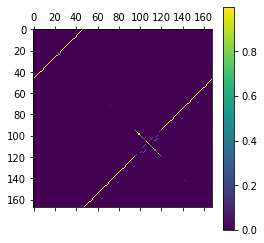

Complex = [A+A]
    Strand indices = [0, 0]
    Concentration = 1.805e-11 M
    Complex free energy = -13.298 kcal/mol
    MFE = -9.954 kcal/mol
    MFE structure = .......((((((((.((((((..+.......)))))))).))))))..


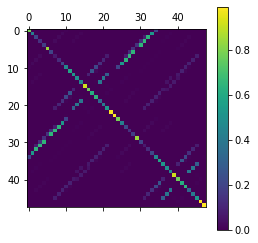

Complex = [A+B+B+B+C+C]
    Strand indices = [0, 1, 1, 1, 2, 2]
    Concentration = 1.106e-07 M
    Complex free energy = -225.604 kcal/mol
    MFE = -223.007 kcal/mol
    MFE structure = (((((((((((((((((((((((.+.)))))))))))))))))))))))((((((((((((((((((((((((+((((((((((((((((((((((((((((((((((((((((((((((((+((((((((((((((((((((((((((..((((((...))))..)).))+))))))))))))))))))))))))))))))))))))))))))))))))+))))))))))))))))))))))))))))))))))))))))))))))))


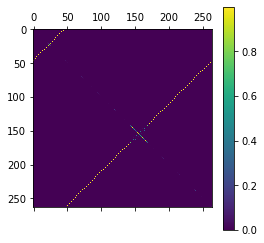

Complex = [A+C+C]
    Strand indices = [0, 2, 2]
    Concentration = 2.054e-18 M
    Complex free energy = -76.974 kcal/mol
    MFE = -72.663 kcal/mol
    MFE structure = ((((((((((((((((((......+((((((((((((((((((......))))))))))))))))))((((..+.(((........)))..))))...))))))))))))))))))......


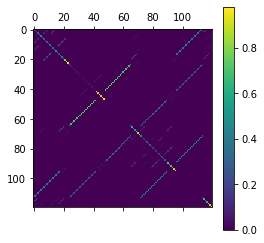

Complex = [A+A+B+C]
    Strand indices = [0, 0, 1, 2]
    Concentration = 4.409e-15 M
    Complex free energy = -96.838 kcal/mol
    MFE = -91.544 kcal/mol
    MFE structure = (((((((((((((((((((((((.+.....(.(((((.....)))))..+))))))))))))))))))))))))((((((((((((((((((((((((+.......(((((.....)))))..))))))))))))))))))))))))


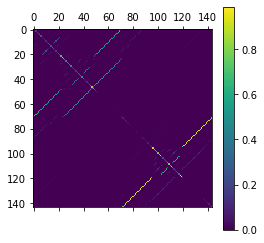

Complex = [A+B+C+C]
    Strand indices = [0, 1, 2, 2]
    Concentration = 4.364e-13 M
    Complex free energy = -129.001 kcal/mol
    MFE = -125.044 kcal/mol
    MFE structure = (((((((((((((((((((((((.+.)))))))))))))))))))))))((((((((((((((((((((((((+((((((((((((((((((......))))))))))))))))))((((..+.(((........)))..))))...))))))))))))))))))))))))


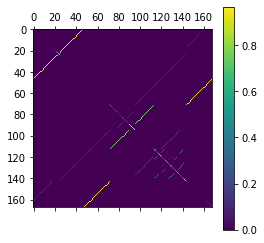

Complex = [A+A+B]
    Strand indices = [0, 0, 1]
    Concentration = 1.076e-10 M
    Complex free energy = -58.438 kcal/mol
    MFE = -55.163 kcal/mol
    MFE structure = .((((.(((((..((.((......+(((((((((((((((((((((((.+.)))))))))))))))))))))))))..))))))).))))........


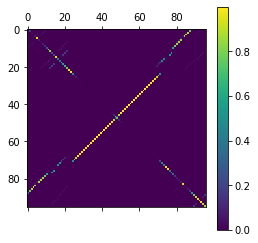

Complex = [A+B+A+B]
    Strand indices = [0, 1, 0, 1]
    Concentration = 1.350e-10 M
    Complex free energy = -103.472 kcal/mol
    MFE = -100.517 kcal/mol
    MFE structure = (((((((((((((((((((((((.+.)))))))))))))))))))))))((..(((((((.(((((..((.((+(((((((((((((((((((((((.+.)))))))))))))))))))))))))..))))))).)))))..)).))


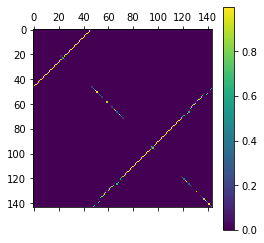

Complex = [C+C+C+C]
    Strand indices = [2, 2, 2, 2]
    Concentration = 1.294e-27 M
    Complex free energy = -138.729 kcal/mol
    MFE = -132.890 kcal/mol
    MFE structure = ((((((((((((((((((......((((((((((((((((((.....(+((((((((((((((((((......((((((((((((((((((......+))))))))))))))))))......))))))))))))))))))....).+))))))))))))))))))......))))))))))))))))))......


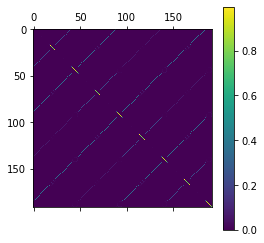

Complex = [A]
    Strand indices = [0]
    Concentration = 3.651e-07 M
    Complex free energy = -3.687 kcal/mol
    MFE = -2.600 kcal/mol
    MFE structure = .......(((((.....)))))..


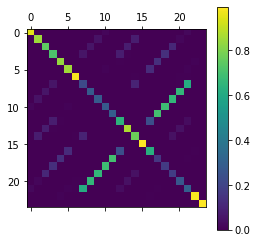

Complex = [A+A+C+C]
    Strand indices = [0, 0, 2, 2]
    Concentration = 7.594e-22 M
    Complex free energy = -87.398 kcal/mol
    MFE = -82.044 kcal/mol
    MFE structure = (((((.((((..(((....)))..+.)))).)))))(((.((((((...+((((((((((((((((((......))))))))))))))))))))))..+((((((((((((((((((......)))))))))))))))))))).)))


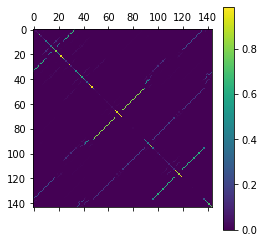

Complex = [A+C]
    Strand indices = [0, 2]
    Concentration = 1.200e-12 M
    Complex free energy = -40.532 kcal/mol
    MFE = -37.881 kcal/mol
    MFE structure = .(((........)))..((((...+((((((((((((((((((......))))))))))))))))))))))..


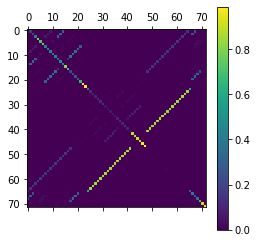

Complex = [B+C+C+C]
    Strand indices = [1, 2, 2, 2]
    Concentration = 8.768e-28 M
    Complex free energy = -137.476 kcal/mol
    MFE = -132.344 kcal/mol
    MFE structure = ....((((((((((((((((((((......))))))))))))))))))+((((((((((((((((((......((((((((((((((((((......+))))))))))))))))))......)))))))))))))))))).....)+((((((((((((((((((......)))))))))))))))))).....)


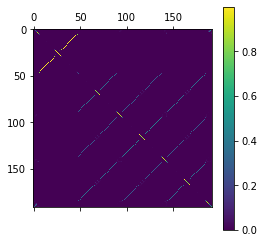

Complex = [B+C]
    Strand indices = [1, 2]
    Concentration = 6.039e-15 M
    Complex free energy = -66.443 kcal/mol
    MFE = -63.881 kcal/mol
    MFE structure = .....(((((((((((((((((((......))))))))))))))))))+((((((((((((((((((......)))))))))))))))))).....)


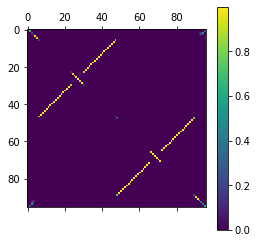

Complex = [C+C]
    Strand indices = [2, 2]
    Concentration = 3.430e-14 M
    Complex free energy = -68.100 kcal/mol
    MFE = -66.554 kcal/mol
    MFE structure = ((((((((((((((((((......((((((((((((((((((......+))))))))))))))))))......))))))))))))))))))......


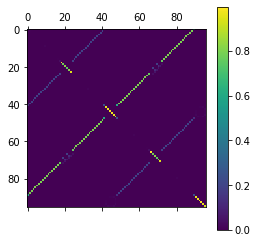

Complex = [B+C+B+C]
    Strand indices = [1, 2, 1, 2]
    Concentration = 2.942e-29 M
    Complex free energy = -135.652 kcal/mol
    MFE = -129.717 kcal/mol
    MFE structure = .....(((((((((((((((((((......((((((((((((((((((+((((((((((((((((((......)))))))))))))))))).....(+.....)))))))))))))))))))......))))))))))))))))))+((((((((((((((((((......)))))))))))))))))).....)


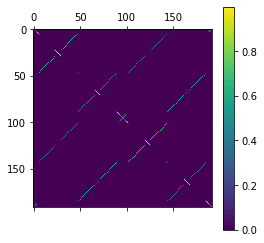

Complex = [A+B+B]
    Strand indices = [0, 1, 1]
    Concentration = 4.873e-14 M
    Complex free energy = -82.865 kcal/mol
    MFE = -78.863 kcal/mol
    MFE structure = (((((((((((((((((((((((.+.)))))))))))))))))))))))......((((...)))).((....+....))((((((((((((((((((......))))))))))))))))))


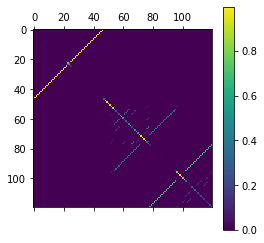

Complex = [A+A+A+B]
    Strand indices = [0, 0, 0, 1]
    Concentration = 2.266e-14 M
    Complex free energy = -68.515 kcal/mol
    MFE = -62.744 kcal/mol
    MFE structure = .(((...(((((.....)))))..+.((((.(((((..((.((......+(((((((((((((((((((((((.+.)))))))))))))))))))))))))..))))))).))))..)))...


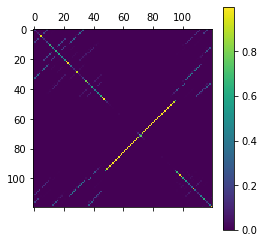

Complex = [A+B+B+B]
    Strand indices = [0, 1, 1, 1]
    Concentration = 1.588e-20 M
    Complex free energy = -118.127 kcal/mol
    MFE = -113.844 kcal/mol
    MFE structure = (((((((((((((((((((((((.+.)))))))))))))))))))))))............((....((....+....))((((((((((((((((((......))))))))))))))))))+....))((((((((((((((((((......))))))))))))))))))


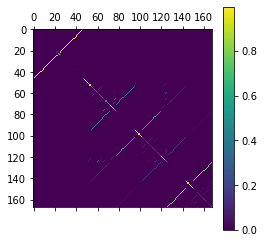

Complex = [A+C+A+C]
    Strand indices = [0, 2, 0, 2]
    Concentration = 3.308e-22 M
    Complex free energy = -87.313 kcal/mol
    MFE = -81.517 kcal/mol
    MFE structure = .((((.((((.......((((...+((((((((((((((((((......))))))))))))))))))))))..+.)))).)))).......((((...+((((((((((((((((((......))))))))))))))))))))))..


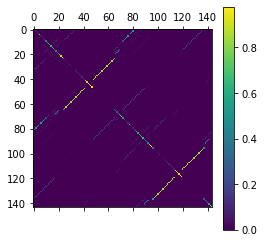

Complex = [B+B+C]
    Strand indices = [1, 1, 2]
    Concentration = 1.464e-22 M
    Complex free energy = -100.103 kcal/mol
    MFE = -96.463 kcal/mol
    MFE structure = .....(((((((((((((((((((......((((((((((((((((((+......))))))))))))))))))......))))))))))))))))))+((((((((((((((((((......)))))))))))))))))).....)


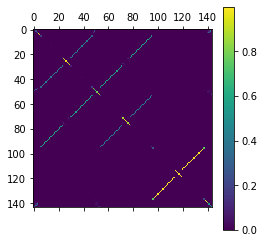

Complex = [A+A+B+B]
    Strand indices = [0, 0, 1, 1]
    Concentration = 1.610e-15 M
    Complex free energy = -96.058 kcal/mol
    MFE = -90.344 kcal/mol
    MFE structure = .((((.(((((..((.((......+(((((((((((((((((((((((.+.)))))))))))))))))))))))))..))))))).))))..((....+....))((((((((((((((((((......))))))))))))))))))


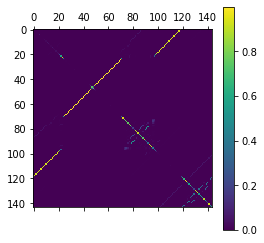

Complex = [C]
    Strand indices = [2]
    Concentration = 2.394e-07 M
    Complex free energy = -32.759 kcal/mol
    MFE = -32.400 kcal/mol
    MFE structure = ((((((((((((((((((......))))))))))))))))))......


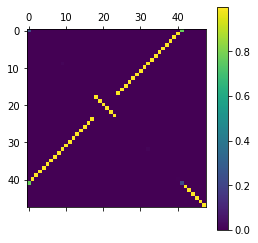

Complex = [A+C+B]
    Strand indices = [0, 2, 1]
    Concentration = 1.498e-15 M
    Complex free energy = -80.878 kcal/mol
    MFE = -77.163 kcal/mol
    MFE structure = (((((((((((((((((((((((.+((((((((((((((((((......))))))))))))))))))(.....+))))))))))))))))))))))))((..((((((...))))..)).))


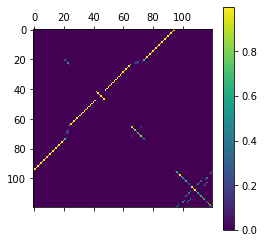

Complex = [A+B+C+B]
    Strand indices = [0, 1, 2, 1]
    Concentration = 1.633e-17 M
    Complex free energy = -122.560 kcal/mol
    MFE = -118.344 kcal/mol
    MFE structure = .((((((((((((((((((((((.+.))))))))))))))))))))))(((((((((((((((((((((((((+.......(((((.....)))))..))))))))))))))))))))))))+...)..((((((((((((((((((......))))))))))))))))))


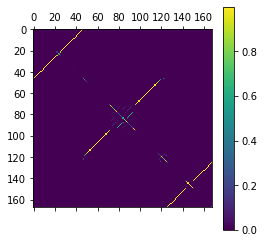

Complex = [A+B+B+C+C]
    Strand indices = [0, 1, 1, 2, 2]
    Concentration = 9.186e-08 M
    Complex free energy = -181.023 kcal/mol
    MFE = -178.425 kcal/mol
    MFE structure = (((((((((((((((((((((((.+.)))))))))))))))))))))))((((((((((((((((((((((((+((((((((((((((((((((((((((((((((((((((((((((((((+.......(((((.....)))))..))))))))))))))))))))))))+))))))))))))))))))))))))))))))))))))))))))))))))


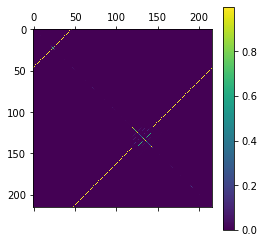

Complex = [C+C+C]
    Strand indices = [2, 2, 2]
    Concentration = 4.541e-21 M
    Complex free energy = -103.214 kcal/mol
    MFE = -98.486 kcal/mol
    MFE structure = ((((((((((((((((((......((((((((((((((((((.....(+((((((((((((((((((......))))))))))))))))))....).+))))))))))))))))))......))))))))))))))))))......


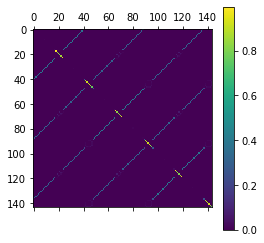

Complex = [B+C+C]
    Strand indices = [1, 2, 2]
    Concentration = 3.305e-21 M
    Complex free energy = -102.183 kcal/mol
    MFE = -98.463 kcal/mol
    MFE structure = .....(((((((((((((((((((......))))))))))))))))))+((((((((((((((((((......((((((((((((((((((......+))))))))))))))))))......)))))))))))))))))).....)


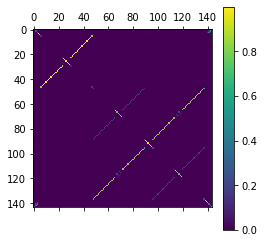

Complex = [A+A+C+B]
    Strand indices = [0, 0, 2, 1]
    Concentration = 9.200e-19 M
    Complex free energy = -91.614 kcal/mol
    MFE = -86.644 kcal/mol
    MFE structure = .((((.(((((..((.((......+(((((((((((((((((((((((.+((((((((((((((((((......))))))))))))))))))(.....+))))))))))))))))))))))))))..))))))).))))........


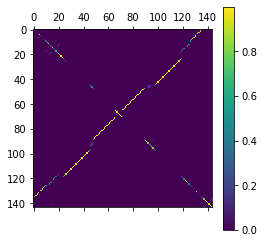

Complex = [A+B]
    Strand indices = [0, 1]
    Concentration = 1.763e-07 M
    Complex free energy = -47.705 kcal/mol
    MFE = -45.681 kcal/mol
    MFE structure = (((((((((((((((((((((((.+.)))))))))))))))))))))))((..((((((...))))..)).))


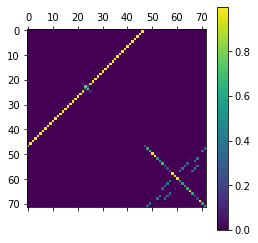

Complex = [A+C+C+C]
    Strand indices = [0, 2, 2, 2]
    Concentration = 3.267e-24 M
    Complex free energy = -113.371 kcal/mol
    MFE = -107.644 kcal/mol
    MFE structure = (((((((((((((((((((((...+((((((((((((((((((......)))))))))))))))))))))...+((((((((((((((((((......))))))))))))))))))((((..+.(((........)))..))))...))))))))))))))))))......


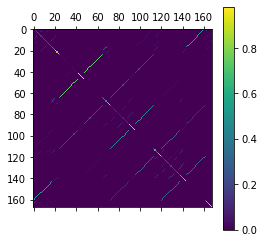

Complex = [B+B]
    Strand indices = [1, 1]
    Concentration = 2.791e-16 M
    Complex free energy = -64.817 kcal/mol
    MFE = -62.354 kcal/mol
    MFE structure = ......((((((((((((((((((......((((((((((((((((((+......))))))))))))))))))......))))))))))))))))))


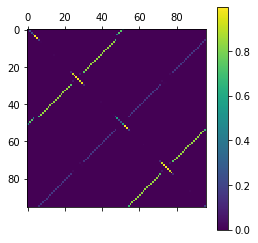

Complex = [A+C+B+C]
    Strand indices = [0, 2, 1, 2]
    Concentration = 9.854e-16 M
    Complex free energy = -125.246 kcal/mol
    MFE = -121.244 kcal/mol
    MFE structure = (((((((((((((((((((((((.+((((((((((((((((((......))))))))))))))))))(.....+))))))))))))))))))))))))((((((((((((((((((((((((+.......(((((.....)))))..))))))))))))))))))))))))


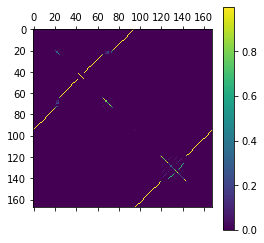

Complex = [A+A+A]
    Strand indices = [0, 0, 0]
    Concentration = 1.622e-15 M
    Complex free energy = -23.100 kcal/mol
    MFE = -17.186 kcal/mol
    MFE structure = .((((.((((((.(((((((((..+.......))))).)))).).....+))))).))))..(((....)))..


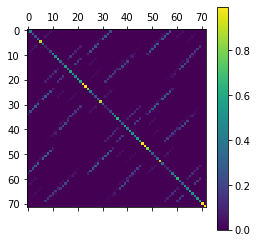

Complex = [B+B+B+C]
    Strand indices = [1, 1, 1, 2]
    Concentration = 8.857e-30 M
    Complex free energy = -134.326 kcal/mol
    MFE = -128.944 kcal/mol
    MFE structure = .....(((((((((((((((((((......((((((((((((((((((+((((..((((((((((((((((((......))))))))))))))))))+))))..))))))))))))))))))......))))))))))))))))))+((((((((((((((((((......)))))))))))))))))).....)


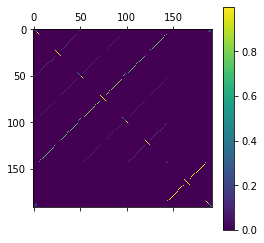

In [5]:
# tube = Tube(strands=strands, max_size=4, additional_complexes=additional_complexes)
# shows the sequences of the complexes in the tube
for cx, res in result.complexes.items():
    print('Complex =', cx)
    print('    Strand indices =', [strands.index(strand) for strand in cx])
    print('    Concentration = %.3e M' % result[tube].complex_concentrations[cx])
    print('    Complex free energy = %.3f kcal/mol' % res.free_energy)
    print('    MFE = %.3f kcal/mol' % res.min_free_energy)
    print('    MFE structure = %s' % res.suboptimal_structures[0][0])
    plt.matshow(res.pair_probability, cmap='viridis')
    plt.colorbar()
    plt.grid(False)
    plt.show()    

# Example 4: 

Design a sequence for a complex of three DNA strands intended to adopt a target secondary structure at 23 ◦C. The first 24 nucleotides are constrained to nucleotide H (corresponding to a 3-letter alphabet) and the specified list of patterns are prevented throughout. A seed is set to make the design repeatable.

# Input file contents:

```
((((((((((((((((((((((((+((((((((((((((((((((((((.......................
.+))))))))))))))))))))))))))))))))))))))))))))))))
HHHHHHHHHHHHHHHHHHHHHHHH
```

# Prevent file contents:

```
AAAA
CCCC
GGGG
UUUU
KKKKKK
MMMMMM
RRRRRR
SSSSSS
WWWWWW
YYYYYY
```

# Seed file contents:

```
93
```

# Command: 

```bash
complexdesign -T 23 -material dna -pairs -loadseed -prevent $NUPACKHOME/doc/examples/complex-design/advanced/input/hcr-design.prevent $NUPACKHOME/doc/examples/complex-design/advanced/input/hcr-design
```

In [6]:
a = Domain('a', 'H24')
b = Domain('b', 'N48')
c = Domain('c', 'N48')

A = Strand('A', [a])
B = Strand('B', [b]) 
C = Strand('C', [c])

x = TargetComplex('x', [A,B,C], '(24+(24.24+)48')

result = complex_design([x], 
    model=Model(material='dna', celsius=23), 
    parameters=design.Parameters(seed=93),
    hard_constraints=[Pattern(["A4", "C4", "G4", "U4", "K6", "M6", "R6", "S6", "W6", "Y6"])]
)

result

,name,value
0,a,CCATTCCACATTAACTTCAACTCA
1,a*,TGAGTTGAAGTTAATGTGGAATGG
2,b,CGGGTCTAGGCTGCTGCGCCTCCGAGGTGGAAGTGAGGATGATGGGAG
3,b*,CTCCCATCATCCTCACTTCCACCTCGGAGGCGCAGCAGCCTAGACCCG
4,c,CGGAGGCGCAGCAGCCTAGACCCGTGAGTTGAAGTTAATGTGGAATGG
5,c*,CCATTCCACATTAACTTCAACTCACGGGTCTAGGCTGCTGCGCCTCCG
6,A,CCATTCCACATTAACTTCAACTCA
7,B,CGGGTCTAGGCTGCTGCGCCTCCGAGGTGGAAGTGAGGATGATGGGAG
8,C,CGGAGGCGCAGCAGCCTAGACCCGTGAGTTGAAGTTAATGTGGAATGG
,defect,weighted


# Example 5: Test tube design. 

Design a sequence for a target test tube at default temperature 37 ◦C. The target test tube contains 1 on-target dimer (with a target structure and target concentration) and all off-target complexes of up to 2 strands (each with vanishing target concentration).

## Script file contents:

```python
# set properties
material = dna
seed = 93 # set seed to make design repeatable
# define target structure for 1 on-target complex
structure legs = ((((((((((((((((((((.......................+.......................))))))))))))))))))))
# define target test tube containing 1 on-target complex
tube walker = legs
# define target concentration for 1 on-target complex (molar)
# default: 1.0e-6
walker.legs.conc = 1.0e-6
# augment tube with all off-target complexes of up to 2 strands
# default: 0
walker.maxsize = 2
```

## Command: 

```bash
tubedesign $NUPACKHOME/doc/examples/tube-design/simple/input/walker-design
```

In [7]:
model = Model(material='DNA')
left = Domain('left', 'N43')
right = Domain('right', 'N43')
sleft = Strand('sleft', [left])
sright = Strand('sright', [right])

legs = TargetComplex('legs', [sleft, sright], structure='(20.23+.23)20')

tube = TargetTube('walker', {legs: 1e-6}, max_size=2)

result = tube_design([tube], model, parameters=design.Parameters(seed=93))
result

Result(mapping=Mapping(tubes={Tube('walker', strands={Strand('sleft', (Domain('left', Sequence('NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN')),)): 1e-06, Strand('sright', (Domain('right', Sequence('NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN')),)): 1e-06}, complexes=[Complex([Strand('sleft', (Domain('left', Sequence('NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN')),))]), Complex([Strand('sleft', (Domain('left', Sequence('NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN')),)), Strand('sleft', (Domain('left', Sequence('NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN')),))]), Complex('legs', [Strand('sleft', (Domain('left', Sequence('NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN')),)), Strand('sright', (Domain('right', Sequence('NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN')),))]), Complex([Strand('sright', (Domain('right', Sequence('NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN')),))]), Complex([Strand('sright', (Domain('right', Sequence('NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN')),)), Strand('sright', (Domain('right', Sequence('NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN')),))])]): Tube('walker', strands={Strand('sleft', (Domain('left', Sequence('GCTGGCAGGGGGTGGTCGTGTTTTTTTTTGGGGCTGATATTAC')),)): 1e-08, Strand('sright', (Domain('right', Sequence('TTTTTGTGGTGGGTGATTGTGGGCACGACCACCCCCTGCCAGC')),)): 1e-08}, complexes=[Complex('[sright]', [Strand('sright', (Domain('right', Sequence('TTTTTGTGGTGGGTGATTGTGGGCACGACCACCCCCTGCCAGC')),))]), Complex('[sright+sright]', [Strand('sright', (Domain('right', Sequence('TTTTTGTGGTGGGTGATTGTGGGCACGACCACCCCCTGCCAGC')),)), Strand('sright', (Domain('right', Sequence('TTTTTGTGGTGGGTGATTGTGGGCACGACCACCCCCTGCCAGC')),))]), Complex('legs', [Strand('sleft', (Domain('left', Sequence('GCTGGCAGGGGGTGGTCGTGTTTTTTTTTGGGGCTGATATTAC')),)), Strand('sright', (Domain('right', Sequence('TTTTTGTGGTGGGTGATTGTGGGCACGACCACCCCCTGCCAGC')),))]), Complex('[sleft]', [Strand('sleft', (Domain('left', Sequence('GCTGGCAGGGGGTGGTCGTGTTTTTTTTTGGGGCTGATATTAC')),))]), Complex('[sleft+sleft]', [Strand('sleft', (Domain('left', Sequence('GCTGGCAGGGGGTGGTCGTGTTTTTTTTTGGGGCTGATATTAC')),)), Strand('sleft', (Domain('left', Sequence('GCTGGCAGGGGGTGGTCGTGTTTTTTTTTGGGGCTGATATTAC')),))])])}, complexes={Complex([Strand('sleft', (Domain('left', Sequence('NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN')),)), Strand('sleft', (Domain('left', Sequence('NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN')),))]): Complex('[sleft+sleft]', [Strand('sleft', (Domain('left', Sequence('GCTGGCAGGGGGTGGTCGTGTTTTTTTTTGGGGCTGATATTAC')),)), Strand('sleft', (Domain('left', Sequence('GCTGGCAGGGGGTGGTCGTGTTTTTTTTTGGGGCTGATATTAC')),))]), Complex([Strand('sright', (Domain('right', Sequence('NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN')),)), Strand('sright', (Domain('right', Sequence('NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN')),))]): Complex('[sright+sright]', [Strand('sright', (Domain('right', Sequence('TTTTTGTGGTGGGTGATTGTGGGCACGACCACCCCCTGCCAGC')),)), Strand('sright', (Domain('right', Sequence('TTTTTGTGGTGGGTGATTGTGGGCACGACCACCCCCTGCCAGC')),))]), Complex([Strand('sright', (Domain('right', Sequence('NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN')),))]): Complex('[sright]', [Strand('sright', (Domain('right', Sequence('TTTTTGTGGTGGGTGATTGTGGGCACGACCACCCCCTGCCAGC')),))]), Complex([Strand('sleft', (Domain('left', Sequence('NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN')),))]): Complex('[sleft]', [Strand('sleft', (Domain('left', Sequence('GCTGGCAGGGGGTGGTCGTGTTTTTTTTTGGGGCTGATATTAC')),))]), Complex('legs', [Strand('sleft', (Domain('left', Sequence('NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN')),)), Strand('sright', (Domain('right', Sequence('NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN')),))]): Complex('legs', [Strand('sleft', (Domain('left', Sequence('GCTGGCAGGGGGTGGTCGTGTTTTTTTTTGGGGCTGATATTAC')),)), Strand('sright', (Domain('right', Sequence('TTTTTGTGGTGGGTGATTGTGGGCACGACCACCCCCTGCCAGC')),))])}, strands={Strand('sleft', (Domain('left', Sequence('NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN')),)

# Example 6: Test tube ensemble defect. 

Calculate the test tube ensemble defect for a specified set of sequences and target test tube at default temperature 37 ◦C. The target test tube contains 1 on-target dimer (with a target structure and target concentration) and all off-target complexes of up to 2 strands (each with vanishing target concentration).

## Script file contents:

```python
# set properties
material = dna
# define 2 sequence domains
domain a = CGTGAACATCGGCGTGGTCGACCAACCCCACACAAAAAACCTA
domain b = TTCCCTCTATATTTCTACACTCCCGACCACGCCGATGTTCACG
# define 2 strands
strand leg1 = a
strand leg2 = b
# define target structure for 1 on-target complex
structure legs = ((((((((((((((((((((.......................+.......................))))))))))))))))))))
# define strand ordering for 1 on-target complex
legs.seq = leg1 leg2
# define target test tube containing 1 on-target complex
tube walker = legs
# define target concentration for 1 on-target complex (molar)
# default:  1.0e-6
walker.legs.conc = 1.0e-6
# augment tube with all off-target complexes of up to 2 strands
# default:  0
walker.maxsize = 2
```

## Command: 

```bash
tubedefect $NUPACKHOME/doc/examples/tube-design/simple/input/walker-defect
```

In [8]:
model = Model(material='DNA')

a = Domain('a', 'CGTGAACATCGGCGTGGTCGACCAACCCCACACAAAAAACCTA')
b = Domain('b', 'TTCCCTCTATATTTCTACACTCCCGACCACGCCGATGTTCACG')

leg1 = Strand('leg1', [a])
leg2 = Strand('leg2', [b])

legs = TargetComplex('legs', [leg1, leg2], structure='(20.23+.23)20')

walker = TargetTube('walker', {legs: 1e-6}, max_size=2)
tube_evaluate([walker], model)

Result(mapping=Mapping(tubes={Tube('walker', strands={Strand('leg1', (Domain('a', Sequence('CGTGAACATCGGCGTGGTCGACCAACCCCACACAAAAAACCTA')),)): 1e-06, Strand('leg2', (Domain('b', Sequence('TTCCCTCTATATTTCTACACTCCCGACCACGCCGATGTTCACG')),)): 1e-06}, complexes=[Complex([Strand('leg2', (Domain('b', Sequence('TTCCCTCTATATTTCTACACTCCCGACCACGCCGATGTTCACG')),))]), Complex([Strand('leg2', (Domain('b', Sequence('TTCCCTCTATATTTCTACACTCCCGACCACGCCGATGTTCACG')),)), Strand('leg2', (Domain('b', Sequence('TTCCCTCTATATTTCTACACTCCCGACCACGCCGATGTTCACG')),))]), Complex('legs', [Strand('leg1', (Domain('a', Sequence('CGTGAACATCGGCGTGGTCGACCAACCCCACACAAAAAACCTA')),)), Strand('leg2', (Domain('b', Sequence('TTCCCTCTATATTTCTACACTCCCGACCACGCCGATGTTCACG')),))]), Complex([Strand('leg1', (Domain('a', Sequence('CGTGAACATCGGCGTGGTCGACCAACCCCACACAAAAAACCTA')),))]), Complex([Strand('leg1', (Domain('a', Sequence('CGTGAACATCGGCGTGGTCGACCAACCCCACACAAAAAACCTA')),)), Strand('leg1', (Domain('a', Sequence('CGTGAACATCGGCGTGGTCGACCAACCCCACACAAAAAACCTA')),))])]): Tube('walker', strands={Strand('leg1', (Domain('a', Sequence('CGTGAACATCGGCGTGGTCGACCAACCCCACACAAAAAACCTA')),)): 1e-08, Strand('leg2', (Domain('b', Sequence('TTCCCTCTATATTTCTACACTCCCGACCACGCCGATGTTCACG')),)): 1e-08}, complexes=[Complex('[leg1]', [Strand('leg1', (Domain('a', Sequence('CGTGAACATCGGCGTGGTCGACCAACCCCACACAAAAAACCTA')),))]), Complex('[leg1+leg1]', [Strand('leg1', (Domain('a', Sequence('CGTGAACATCGGCGTGGTCGACCAACCCCACACAAAAAACCTA')),)), Strand('leg1', (Domain('a', Sequence('CGTGAACATCGGCGTGGTCGACCAACCCCACACAAAAAACCTA')),))]), Complex('legs', [Strand('leg1', (Domain('a', Sequence('CGTGAACATCGGCGTGGTCGACCAACCCCACACAAAAAACCTA')),)), Strand('leg2', (Domain('b', Sequence('TTCCCTCTATATTTCTACACTCCCGACCACGCCGATGTTCACG')),))]), Complex('[leg2]', [Strand('leg2', (Domain('b', Sequence('TTCCCTCTATATTTCTACACTCCCGACCACGCCGATGTTCACG')),))]), Complex('[leg2+leg2]', [Strand('leg2', (Domain('b', Sequence('TTCCCTCTATATTTCTACACTCCCGACCACGCCGATGTTCACG')),)), Strand('leg2', (Domain('b', Sequence('TTCCCTCTATATTTCTACACTCCCGACCACGCCGATGTTCACG')),))])])}, complexes={Complex('legs', [Strand('leg1', (Domain('a', Sequence('CGTGAACATCGGCGTGGTCGACCAACCCCACACAAAAAACCTA')),)), Strand('leg2', (Domain('b', Sequence('TTCCCTCTATATTTCTACACTCCCGACCACGCCGATGTTCACG')),))]): Complex('legs', [Strand('leg1', (Domain('a', Sequence('CGTGAACATCGGCGTGGTCGACCAACCCCACACAAAAAACCTA')),)), Strand('leg2', (Domain('b', Sequence('TTCCCTCTATATTTCTACACTCCCGACCACGCCGATGTTCACG')),))]), Complex([Strand('leg1', (Domain('a', Sequence('CGTGAACATCGGCGTGGTCGACCAACCCCACACAAAAAACCTA')),))]): Complex('[leg1]', [Strand('leg1', (Domain('a', Sequence('CGTGAACATCGGCGTGGTCGACCAACCCCACACAAAAAACCTA')),))]), Complex([Strand('leg2', (Domain('b', Sequence('TTCCCTCTATATTTCTACACTCCCGACCACGCCGATGTTCACG')),)), Strand('leg2', (Domain('b', Sequence('TTCCCTCTATATTTCTACACTCCCGACCACGCCGATGTTCACG')),))]): Complex('[leg2+leg2]', [Strand('leg2', (Domain('b', Sequence('TTCCCTCTATATTTCTACACTCCCGACCACGCCGATGTTCACG')),)), Strand('leg2', (Domain('b', Sequence('TTCCCTCTATATTTCTACACTCCCGACCACGCCGATGTTCACG')),))]), Complex([Strand('leg2', (Domain('b', Sequence('TTCCCTCTATATTTCTACACTCCCGACCACGCCGATGTTCACG')),))]): Complex('[leg2]', [Strand('leg2', (Domain('b', Sequence('TTCCCTCTATATTTCTACACTCCCGACCACGCCGATGTTCACG')),))]), Complex([Strand('leg1', (Domain('a', Sequence('CGTGAACATCGGCGTGGTCGACCAACCCCACACAAAAAACCTA')),)), Strand('leg1', (Domain('a', Sequence('CGTGAACATCGGCGTGGTCGACCAACCCCACACAAAAAACCTA')),))]): Complex('[leg1+leg1]', [Strand('leg1', (Domain('a', Sequence('CGTGAACATCGGCGTGGTCGACCAACCCCACACAAAAAACCTA')),)), Strand('leg1', (Domain('a', Sequence('CGTGAACATCGGCGTGGTCGACCAACCCCACACAAAAAACCTA')),))])}, strands={Strand('leg1', (Domain('a', Sequence('CGTGAACATCGGCGTGGTCGACCAACCCCACACAAAAAACCTA')),)): Strand('leg1', (Domain('a', Sequence('CGTGAACATCGGCGTGGTCGACCAACCCCACACAAAAAACCTA')),)), Strand('leg2', (Domain('b', Sequence('TTCCCTCTATATTTCTACACTCCCGACCACGCCGATGTTCACG')),)): Strand('leg2', (Domai